# Capstone Project — Personal Fitness Analytics

## Introduction

**Dataset.** Six years of personal strength-training logs (May 2020 – May 2026), exported from the
[Strong](https://www.strong.app/) app: ~23,000 rows, one row per logged set, semicolon-delimited.
Every row carries a workout id, timestamp, workout duration, exercise name, set order, weight (kg)
and reps. The data is self-collected and was never intended for analysis, which makes it a realistic
cleaning exercise: it mixes real working sets with warmups, rest-timer entries, free-text notes and
occasional data-entry errors.

**Why this dataset.** It is longitudinal (6 years, uninterrupted), it is granular (set level, not
session level), and its quality problems are genuine rather than artificial — exactly the conditions
in which data preparation decisions actually matter and have to be defended.

### Research questions

| # | Question | Answered in |
|---|---|---|
| **RQ1** | How did total training volume develop over the six years — is there measurable growth? | `03_statistics` §4 |
| **RQ2** | How did strength (estimated 1RM) develop per key exercise, and how fast? | `03_statistics` §5, §7 |
| **RQ3** | Does training *more often* in a month go together with *higher* strength that month? | `03_statistics` §6 |
| **RQ4** | What temporal patterns exist — training frequency, weekday habits, consistency? | `03_statistics` §3, §9 |
| **RQ5** | How does this training compare to external reference points (strength standards, another lifter)? | `04_comparison`, Streamlit dashboard |

### Methodology

1. **Data preparation** (this notebook) — inspect, document and clean the raw export; engineer the
   analytical features (volume, estimated 1RM); aggregate to workout level; export two tidy datasets.
2. **Relational modelling** (`02_sql_setup`) — load into SQLite, answer analytical questions in SQL.
3. **Statistics & visualisation** (`03_statistics`) — descriptive statistics, distributions,
   correlation analysis with significance testing, linear trend models, and the answers to RQ1–RQ4.
4. **Dashboards** (Power BI, Streamlit) — interactive presentation of the same cleaned data.
5. **Comparative analysis** (`04_comparison`) — benchmarking against a second lifter's public dataset.

**Tools:** Python (pandas, NumPy, Matplotlib, seaborn, SciPy), SQLite, Power BI, Streamlit.

---

## This notebook — Phase 1: Data Cleaning & Feature Engineering

**Goal:** Transform the raw, set-level export into two clean, analysis-ready datasets.

**Output:**
- `data/clean/clean_sets.csv` — one row per working set, with engineered features
- `data/clean/workout_summary.csv` — one row per workout, aggregated metrics

---
### Notebook structure
1. Setup & Load
2. Exploratory Inspection (structure, missing values, duplicates)
3. Filter & Clean (row types, type casting, outliers)
4. Feature Engineering
5. Workout-Level Aggregation & Quality Filter
6. Export

## 1. Setup & Load

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)
sns.set_theme(style="whitegrid", palette="muted")

In [2]:
# Resolve raw file — look in data/raw first, fall back to project root
_candidates = [
    Path("../data/raw/strong_userdata.csv"),
    Path("../strong_userdata.csv"),
]
RAW_FILE = next((p for p in _candidates if p.exists()), None)
assert RAW_FILE is not None, "strong_userdata.csv not found. Place it in data/raw/ or the project root."

CLEAN_DIR = Path("../data/clean")
CLEAN_DIR.mkdir(parents=True, exist_ok=True)

print(f"Raw file : {RAW_FILE.resolve()}")
print(f"Clean dir: {CLEAN_DIR.resolve()}")

Raw file : C:\projects\FitnessData\data\raw\strong_userdata.csv
Clean dir: C:\projects\FitnessData\data\clean


In [3]:
# Strong exports use semicolons as delimiters and wraps all values in double quotes
raw = pd.read_csv(
    RAW_FILE,
    sep=";",
    quotechar='"',
    encoding="utf-8",
    dtype=str,          # load everything as string first — we cast deliberately below
    na_values=[""],
)

print(f"Rows: {len(raw):,}  |  Columns: {raw.shape[1]}")
raw.head(3)

Rows: 23,058  |  Columns: 13


,Workout #,Date,Workout Name,Duration (sec),Exercise Name,Set Order,Weight (kg),Reps,RPE,Distance (meters),Seconds,Notes,Workout Notes
0,1,2020-05-28 12:58:47,Day 3,4195,Incline Bench Press (Barbell),W,40.0,15,NaN,NaN,NaN,NaN,NaN
1,1,2020-05-28 12:58:47,Day 3,4195,Incline Bench Press (Barbell),1,60.0,7,NaN,NaN,NaN,NaN,NaN
2,1,2020-05-28 12:58:47,Day 3,4195,Incline Bench Press (Barbell),2,60.0,8,NaN,NaN,NaN,NaN,NaN


## 2. Exploratory Inspection

Before any transformation, understand the shape and quality of the data.

In [4]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23058 entries, 0 to 23057
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Workout #          23058 non-null  object
 1   Date               23058 non-null  object
 2   Workout Name       23058 non-null  object
 3   Duration (sec)     23058 non-null  object
 4   Exercise Name      23058 non-null  object
 5   Set Order          23058 non-null  object
 6   Weight (kg)        19203 non-null  object
 7   Reps               19287 non-null  object
 8   RPE                0 non-null      object
 9   Distance (meters)  23 non-null     object
 10  Seconds            3772 non-null   object
 11  Notes              9 non-null      object
 12  Workout Notes      378 non-null    object
dtypes: object(13)
memory usage: 2.3+ MB


In [5]:
# Null count per column — helps decide which columns are usable
null_pct = (raw.isnull().sum() / len(raw) * 100).round(1)
null_pct.rename("null_%").to_frame()

,null_%
Workout #,0.00
Date,0.00
Workout Name,0.00
Duration (sec),0.00
Exercise Name,0.00
Set Order,0.00
Weight (kg),16.70
Reps,16.40
RPE,100.00
Distance (meters),99.90


**Missing-value strategy.** The nulls are structural, not random, so imputation would be wrong here:

| Column | Null % | Decision |
|---|---|---|
| `RPE`, `Notes` | 100% | Never filled in the app — **drop the column**, nothing to recover |
| `Distance (meters)`, `Seconds` | ~84–100% | Only meaningful for cardio/timed exercises, which this analysis excludes — **drop** |
| `Workout Notes` | 98.4% | Free text, not analysable — **drop** |
| `Weight (kg)`, `Reps` | ~16.5% | **Not** missing measurements: these are the rest-timer and note rows, which carry no set data by design. They disappear with the row-type filter in §3 — verified there |

No imputation is performed anywhere: a set that was not recorded cannot be reconstructed, and
inventing values would corrupt every downstream metric (volume, 1RM, personal records).

In [6]:
# 'Set Order' drives the row type — inspect every distinct value
# Numeric values = working sets; 'W' = warmup; others = metadata rows
print(raw["Set Order"].value_counts(dropna=False).to_string())

Set Order
1             5384
2             5295
3             5264
Rest Timer    3661
4             2202
5              652
W              237
6              193
D              133
7               24
Note             9
8                1
9                1
10               1
11               1


In [7]:
# Date range of the dataset
dates = pd.to_datetime(raw["Date"], errors="coerce")
print(f"Earliest workout : {dates.min().date()}")
print(f"Latest workout   : {dates.max().date()}")
print(f"Span             : {(dates.max() - dates.min()).days} days")

Earliest workout : 2020-05-28
Latest workout   : 2026-05-27
Span             : 2190 days


In [8]:
# Top 20 exercises by raw row count (includes warmups/notes, for orientation)
raw["Exercise Name"].value_counts().head(20)

Exercise Name
Incline Bench Press (Dumbbell)             1014
Lateral Raise (Dumbbell)                    965
Bench Press (Barbell)                       868
Cable Crossover                             746
Lat Pulldown (Cable)                        733
Leg Extension (Machine)                     726
Pull Up                                     723
Romanian Deadlift (Barbell)                 709
Chest Dip                                   653
Bicep Curl (Cable)                          642
Hack Squat                                  556
Seated Leg Curl (Machine)                   548
Pullover (Machine)                          539
Seated Overhead Press (Dumbbell)            528
Seated Leg Press (Machine)                  499
Triceps Extension (Cable)                   494
Lying Leg Curl (Machine)                    477
Shrug (Dumbbell)                            470
Triceps Pushdown (Cable - Straight Bar)     456
Reverse Fly (Machine)                       455
Name: count, dtype: int64

### Duplicate records

A duplicate check has to happen *before* deciding anything, but the raw count on its own is
misleading here — so we look at **which kind of row** the duplicates belong to.

In [9]:
dup_total = raw.duplicated().sum()
print(f"Exact duplicate rows in the raw file: {dup_total:,} ({dup_total / len(raw) * 100:.1f}%)")

# Which row types are involved? Rest-timer rows are identical to each other by design
# (same timestamp, same label, no weight/reps) — they are not real duplicated measurements.
dup_rows = raw[raw.duplicated(keep=False)]
print("\nRows involved in exact duplicates, by 'Set Order' type:")
print(dup_rows["Set Order"].value_counts().to_string())

Exact duplicate rows in the raw file: 2,695 (11.7%)

Rows involved in exact duplicates, by 'Set Order' type:
Set Order
Rest Timer    3626
D               15
1                2
3                2


Almost every duplicate is a `Rest Timer` row — an artefact of how the app logs rest periods, and
those rows are removed by the row-type filter below anyway. The question that actually matters is
whether any **real working set** was logged twice; that is checked directly after the row filter.

## 3. Filter & Clean

`Set Order` encodes the row type. Four non-numeric values appear in the export (see the value counts
above) and each needs an explicit decision:

| `Set Order` | Rows | Meaning | Decision |
|---|---|---|---|
| `Rest Timer` | 3,661 | Auto-logged rest period — no weight/reps | **Drop** — carries no set data |
| `W` | 237 | Warmup set | **Drop** — submaximal by definition; would depress 1RM estimates and inflate set counts |
| `D` | 133 | **Drop set** — continuation of the previous set at reduced weight after failure | **Drop** — see note below |
| `Note` | 9 | Free-text note attached to an exercise | **Drop** — no numeric content |

> **On drop sets (`D`):** these rows *do* contain valid weight and reps, so discarding them is a
> deliberate analytical choice, not a technical necessity. A drop set is not an independent working
> set — it is the tail end of the set before it, performed at a lower weight in an already fatigued
> state. Counting it separately would inflate the set count and distort the "best set" logic behind
> the 1RM estimate. The trade-off: total volume is slightly understated (133 of ~19,000 sets, ≈0.7%).
> This is revisited in the limitations section of `03_statistics`.

We therefore keep only rows where `Set Order` is a positive integer.

In [10]:
# Standardise column names to snake_case before any further work
COLUMN_MAP = {
    "Workout #":        "workout_id",
    "Date":             "date",
    "Workout Name":     "workout_name",
    "Duration (sec)":   "duration_sec",
    "Exercise Name":    "exercise_name",
    "Set Order":        "set_order",
    "Weight (kg)":      "weight_kg",
    "Reps":             "reps",
    "RPE":              "rpe",
    "Distance (meters)": "distance_m",
    "Seconds":          "seconds",
    "Notes":            "notes",
    "Workout Notes":    "workout_notes",
}

df = raw.rename(columns=COLUMN_MAP)

In [11]:
# Keep only rows where set_order is a pure integer string (e.g. '1', '2', '3')
# This is more robust than an exclusion list — it survives any new metadata row types Strong might add
is_working_set = df["set_order"].str.match(r"^\d+$", na=False)

df_sets = df.loc[is_working_set].copy()

dropped = len(df) - len(df_sets)
print(f"Rows removed (warmups, rest timers, notes): {dropped:,}")
print(f"Working sets remaining: {len(df_sets):,}")

Rows removed (warmups, rest timers, notes): 4,040
Working sets remaining: 19,018


In [12]:
# Now that only real working sets remain: was any set logged twice within the same workout?
dup_sets = df_sets.duplicated()
print(f"Duplicate working sets: {dup_sets.sum()}")

if dup_sets.any():
    print("\nAffected rows (every copy shown):")
    print(
        df_sets[df_sets.duplicated(keep=False)]
        [["workout_id", "date", "exercise_name", "set_order", "weight_kg", "reps"]]
        .to_string(index=False)
    )

df_sets = df_sets.drop_duplicates().copy()
print(f"\nWorking sets after duplicate removal: {len(df_sets):,}")

Duplicate working sets: 2

Affected rows (every copy shown):


workout_id                date                    exercise_name set_order weight_kg reps
       204 2021-04-24 15:21:51 Bent Over One Arm Row (Dumbbell)         1      22.0   15
       204 2021-04-24 15:21:51 Bent Over One Arm Row (Dumbbell)         3      22.0   13
       204 2021-04-24 15:21:51 Bent Over One Arm Row (Dumbbell)         1      22.0   15
       204 2021-04-24 15:21:51 Bent Over One Arm Row (Dumbbell)         3      22.0   13



Working sets after duplicate removal: 19,016


In [13]:
# Cast each column to its correct type
# errors='coerce' turns unparseable values into NaN rather than raising — we inspect those after
df_sets = df_sets.assign(
    date         = pd.to_datetime(df_sets["date"], errors="coerce"),
    workout_id   = pd.to_numeric(df_sets["workout_id"], errors="coerce").astype("Int64"),
    duration_sec = pd.to_numeric(df_sets["duration_sec"], errors="coerce").astype("Int64"),
    set_order    = pd.to_numeric(df_sets["set_order"], errors="coerce").astype("Int64"),
    weight_kg    = pd.to_numeric(df_sets["weight_kg"], errors="coerce"),
    reps         = pd.to_numeric(df_sets["reps"], errors="coerce").astype("Int64"),
    rpe          = pd.to_numeric(df_sets["rpe"], errors="coerce"),
)

In [14]:
# Inspect any rows where weight or reps could not be parsed — these would skew calculations
missing_core = df_sets[df_sets["weight_kg"].isna() | df_sets["reps"].isna()]
print(f"Rows with missing weight or reps: {len(missing_core):,}")
missing_core.head(10)

Rows with missing weight or reps: 185


,workout_id,date,workout_name,duration_sec,exercise_name,set_order,weight_kg,reps,rpe,distance_m,seconds,notes,workout_notes
2646,126,2021-01-12 13:42:41,Push Home,5373,Bike ride,1,NaN,<NA>,NaN,0.0,1320.0,NaN,NaN
2653,127,2021-01-13 13:48:42,Home Core,4957,Plank,1,NaN,<NA>,NaN,NaN,60.0,NaN,NaN
2654,127,2021-01-13 13:48:42,Home Core,4957,Plank,2,NaN,<NA>,NaN,NaN,60.0,NaN,NaN
2655,127,2021-01-13 13:48:42,Home Core,4957,Plank,3,NaN,<NA>,NaN,NaN,60.0,NaN,NaN
2656,127,2021-01-13 13:48:42,Home Core,4957,Side Plank,1,NaN,<NA>,NaN,NaN,45.0,NaN,NaN
2657,127,2021-01-13 13:48:42,Home Core,4957,Side Plank,2,NaN,<NA>,NaN,NaN,45.0,NaN,NaN
2658,127,2021-01-13 13:48:42,Home Core,4957,Side Plank,3,NaN,<NA>,NaN,NaN,45.0,NaN,NaN
2659,127,2021-01-13 13:48:42,Home Core,4957,L Sit,1,NaN,<NA>,NaN,NaN,20.0,NaN,NaN
2660,127,2021-01-13 13:48:42,Home Core,4957,L Sit,2,NaN,<NA>,NaN,NaN,20.0,NaN,NaN
2661,127,2021-01-13 13:48:42,Home Core,4957,L Sit,3,NaN,<NA>,NaN,NaN,20.0,NaN,NaN


In [15]:
# Drop rows without usable weight or reps — they cannot contribute to any metric
df_sets = df_sets.dropna(subset=["weight_kg", "reps"]).copy()

# Sanity check: no negative weights or reps
assert (df_sets["weight_kg"] >= 0).all(), "Negative weight values found"
assert (df_sets["reps"] > 0).all(), "Zero or negative rep values found"

print(f"Clean working sets: {len(df_sets):,}")

Clean working sets: 18,831


### Outlier Removal — Reps

Data entry errors in Strong produce physiologically impossible rep counts (e.g. `16814`).
In weighted strength training, sets above **100 reps** are effectively impossible and indicate a typo.
We log every affected row before dropping it so the removal is transparent and reproducible.

In [16]:
# Inspect the upper tail of the reps distribution
print(df_sets["reps"].describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99]).to_string())
print()
print("Top 10 highest-rep sets:")
print(df_sets.nlargest(10, "reps")[["date", "exercise_name", "weight_kg", "reps"]].to_string(index=False))

count   18831.00
mean       14.08
std       122.50
min         1.00
25%        11.00
50%        13.00
75%        16.00
95%        20.00
99%        22.00
max     16814.00

Top 10 highest-rep sets:
               date           exercise_name  weight_kg  reps
2021-01-21 12:15:05   Bicep Curl (Dumbbell)       5.00 16814
2021-05-17 17:01:53  Hip Abductor (Machine)      57.50   146
2021-02-21 12:21:44      Bicep Curl (Cable)       0.00   114
2026-05-25 10:18:30        Wrist Curl Cable      25.00    33
2024-04-07 19:42:44 Leg Extension (Machine)      45.00    31
2020-12-03 13:10:40        Kettlebell Swing      16.00    30
2021-03-12 13:29:55       Cross Body Crunch       0.00    30
2021-03-12 13:29:55                  Crunch       0.00    30
2021-03-15 15:40:01       Cross Body Crunch       0.00    30
2021-03-15 15:40:01       Cross Body Crunch       0.00    30


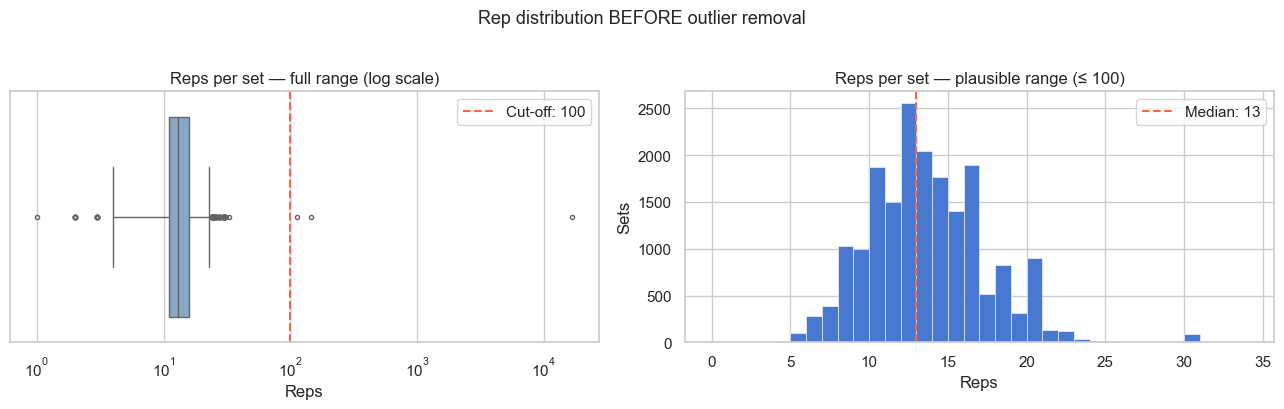

In [17]:
# Physiological ceiling: beyond ~100 reps a "set" is a typo, not a set.
MAX_REPS = 100

reps_all = df_sets["reps"].astype(float)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.boxplot(x=reps_all, ax=axes[0], color="#7fa8d1", fliersize=3)
axes[0].axvline(MAX_REPS, color="tomato", ls="--", lw=1.5, label=f"Cut-off: {MAX_REPS}")
axes[0].set(title="Reps per set — full range (log scale)", xlabel="Reps", xscale="log")
axes[0].legend()

plausible = reps_all[reps_all <= MAX_REPS]
axes[1].hist(plausible, bins=range(0, int(plausible.max()) + 2), edgecolor="white", linewidth=0.4)
axes[1].axvline(plausible.median(), color="tomato", ls="--", lw=1.5,
                label=f"Median: {plausible.median():.0f}")
axes[1].set(title=f"Reps per set — plausible range (≤ {MAX_REPS})", xlabel="Reps", ylabel="Sets")
axes[1].legend()

plt.suptitle("Rep distribution BEFORE outlier removal", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

In [18]:
outliers = df_sets[df_sets["reps"] > MAX_REPS]
if len(outliers) > 0:
    print(f"Removing {len(outliers)} row(s) with reps > {MAX_REPS}:")
    print(outliers[["date", "exercise_name", "weight_kg", "reps"]].to_string(index=False))
else:
    print("No rep outliers found.")

df_sets = df_sets[df_sets["reps"] <= MAX_REPS].copy()
print(f"\nWorking sets after outlier removal: {len(df_sets):,}")

Removing 3 row(s) with reps > 100:
               date          exercise_name  weight_kg  reps
2021-01-21 12:15:05  Bicep Curl (Dumbbell)       5.00 16814
2021-02-21 12:21:44     Bicep Curl (Cable)       0.00   114
2021-05-17 17:01:53 Hip Abductor (Machine)      57.50   146

Working sets after outlier removal: 18,828


### Outlier check — Weight

Weight cannot be checked with one global threshold: 250 kg on a leg press is routine, the same number
on a lateral raise would be nonsense. So each set is compared against **its own exercise's**
distribution, and the most frequent exercises are inspected visually.

Note that `weight_kg == 0` is legitimate and expected — it marks unweighted bodyweight sets
(pull ups, dips, push ups) where only the rep count carries information.

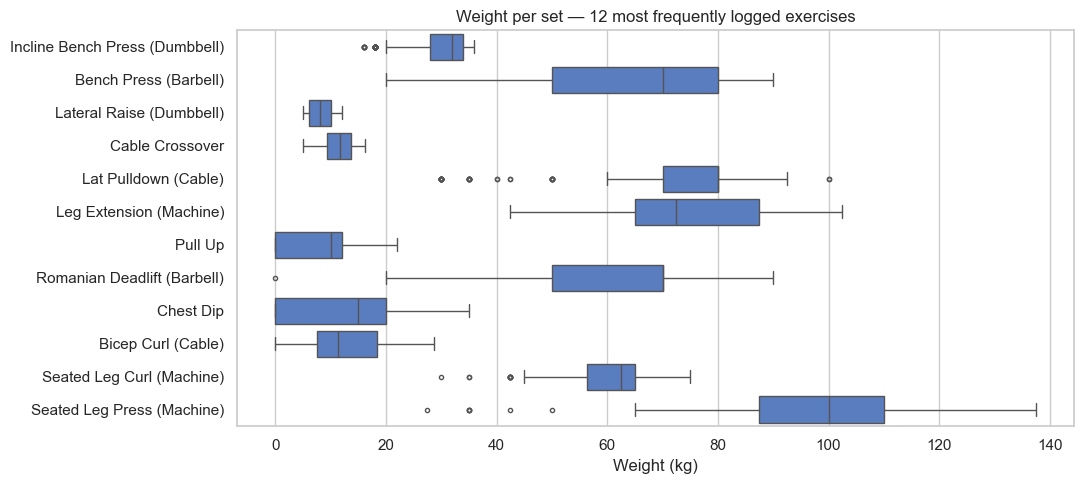

Sets above 3x their own exercise's 99th percentile: 0
No implausible weights found — no rows removed on this criterion.


In [19]:
top_ex = df_sets["exercise_name"].value_counts().head(12).index

fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=df_sets[df_sets["exercise_name"].isin(top_ex)],
            y="exercise_name", x="weight_kg", order=top_ex, ax=ax, fliersize=3)
ax.set(title="Weight per set — 12 most frequently logged exercises", xlabel="Weight (kg)", ylabel="")
plt.tight_layout()
plt.show()

# Flag sets far outside their own exercise's distribution (same rule as Phase 6)
p99 = df_sets.groupby("exercise_name")["weight_kg"].transform(lambda s: s.quantile(0.99))
extreme = df_sets[df_sets["weight_kg"] > p99 * 3]

print(f"Sets above 3x their own exercise's 99th percentile: {len(extreme)}")
if len(extreme) > 0:
    print(extreme[["date", "exercise_name", "weight_kg", "reps"]].to_string(index=False))
else:
    print("No implausible weights found — no rows removed on this criterion.")

**Result: no weight outliers.** Every logged weight sits inside a plausible band for its own
exercise, and the boxplots show the spread is driven by genuine progression and by warm-up-weight
variation within an exercise, not by typos. No rows are removed on this criterion — a negative
finding, but one worth reporting: it means the rep-count errors above were isolated slips rather
than a systematic recording problem. (For contrast, the external dataset cleaned in `04_comparison`
*does* contain such an error — a 2,956 lb squat — and is filtered with exactly this rule.)

## 4. Feature Engineering

### Volume
**Volume** (`weight × reps`) is the standard measure of total mechanical work per set.
Summed across a workout it gives *total volume load* — a key proxy for training stimulus.

### Estimated 1RM (Epley Formula)
The **one-rep maximum** is the gold standard for comparing strength over time.
Because you rarely test a true 1RM, we estimate it from sub-maximal sets:

$$\hat{1RM} = \text{weight} \times \left(1 + \frac{\text{reps}}{30}\right)$$

For single-rep sets the formula slightly overestimates, so we return the raw weight instead.

In [20]:
df_sets = df_sets.assign(
    # Total mechanical work for this set
    volume_kg = df_sets["weight_kg"] * df_sets["reps"],

    # Epley 1RM estimate — clamp to actual weight for single-rep sets
    estimated_1rm = np.where(
        df_sets["reps"] == 1,
        df_sets["weight_kg"],
        df_sets["weight_kg"] * (1 + df_sets["reps"] / 30),
    ),

    # Calendar columns — useful for grouping and trend analysis later
    year  = df_sets["date"].dt.year,
    month = df_sets["date"].dt.to_period("M").astype(str),
    week  = df_sets["date"].dt.to_period("W").astype(str),
    day_of_week = df_sets["date"].dt.day_name(),
)

In [21]:
# Spot-check: top estimated 1RM, one entry per exercise
# Verifies the Epley formula produces plausible results across different movements
sample = (
    df_sets
    .sort_values("estimated_1rm", ascending=False)
    .drop_duplicates(subset="exercise_name")
    .head(5)
    [["date", "exercise_name", "weight_kg", "reps", "estimated_1rm"]]
)
sample

,date,exercise_name,weight_kg,reps,estimated_1rm
886,2020-08-05 14:32:19,Leg Press,250.00,16,383.33
14856,2024-08-16 14:38:24,Hip Adductor (Machine),117.50,23,207.58
587,2020-07-15 15:27:35,Seated Leg Press (Machine),137.50,10,183.33
7483,2022-04-11 09:59:29,Leg Extension (Machine),95.00,22,164.67
14056,2024-06-03 15:30:05,Triceps Extension (Machine),102.50,18,164.00


### Scaling, normalisation & categorical variables

**No scaling or normalisation is applied to the exported data.** Every numeric feature is already in
a directly interpretable physical unit (kg, reps, minutes), and the downstream analyses are
descriptive and statistical rather than distance- or gradient-based, so standardisation would only
cost interpretability. Where a comparison genuinely requires a common scale, it is applied *at
analysis time* instead: `04_comparison` indexes each lifter's 1RM to **their own peak (% of peak)**,
which is what makes two people of unknown bodyweight comparable at all.

**No categorical encoding (one-hot or similar) is applied**, because no model in this project uses a
categorical predictor. `exercise_name` and `workout_name` are used for grouping, filtering and
labelling, where the readable string is the most useful form. The one derived categorical feature —
the exercise → muscle-group mapping used by the dashboard (`streamlit_app/utils.py`) — is a lookup
table for aggregation, not a model encoding.

## 5. Workout-Level Aggregation

Aggregate the set-level data into one row per workout.
This `workout_summary` table is the primary input for time-series and trend analysis.

In [22]:
# Aggregate to one row per workout — deliberately WITHOUT filtering, so that the
# quality filter below can be judged against the full, unfiltered distribution.
workout_summary_all = (
    df_sets
    .groupby(["workout_id", "date", "workout_name", "duration_sec"], dropna=False)
    .agg(
        total_sets        = ("set_order",     "count"),
        total_volume_kg   = ("volume_kg",     "sum"),
        peak_estimated_1rm= ("estimated_1rm", "max"),
        unique_exercises  = ("exercise_name", "nunique"),
    )
    .reset_index()
    .assign(duration_min = lambda x: (x["duration_sec"] / 60).round(1))
    .drop(columns="duration_sec")
    .sort_values("date")
    .reset_index(drop=True)
)

print(f"Workouts before quality filter: {len(workout_summary_all):,}\n")
workout_summary_all[["duration_min", "total_sets", "total_volume_kg"]].describe(
    percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]
).round(1)

Workouts before quality filter: 849



,duration_min,total_sets,total_volume_kg
count,849.00,849.00,849.00
mean,75.70,22.20,11045.30
std,17.20,5.10,6699.60
min,0.60,3.00,0.00
1%,28.20,6.00,0.00
5%,51.20,12.00,954.00
50%,75.90,23.00,10039.20
95%,98.90,29.00,22954.00
99%,131.40,31.00,27711.60
max,182.60,36.00,35145.00


### Workout-level quality filter

Not every logged session is a usable observation. Two failure modes are visible in the raw data:

- **The timer kept running.** Strong measures duration from the first to the last logged set; if the
  workout is never closed in the app, the recorded duration can reach three hours for a normal session.
- **The session was abandoned or only partially logged.** A "workout" of four sets in eleven minutes
  is a fragment, not a training session, and would drag down every per-session average.

The rule applied is `45 ≤ duration ≤ 100 minutes` **and** `total_sets ≥ 15`. This is a judgement call
that removes real rows, so it has to be shown rather than asserted — the plots below give the
distributions the thresholds are drawn on, the table quantifies what is lost, and a sensitivity check
verifies that the project's conclusions do not depend on the filter.

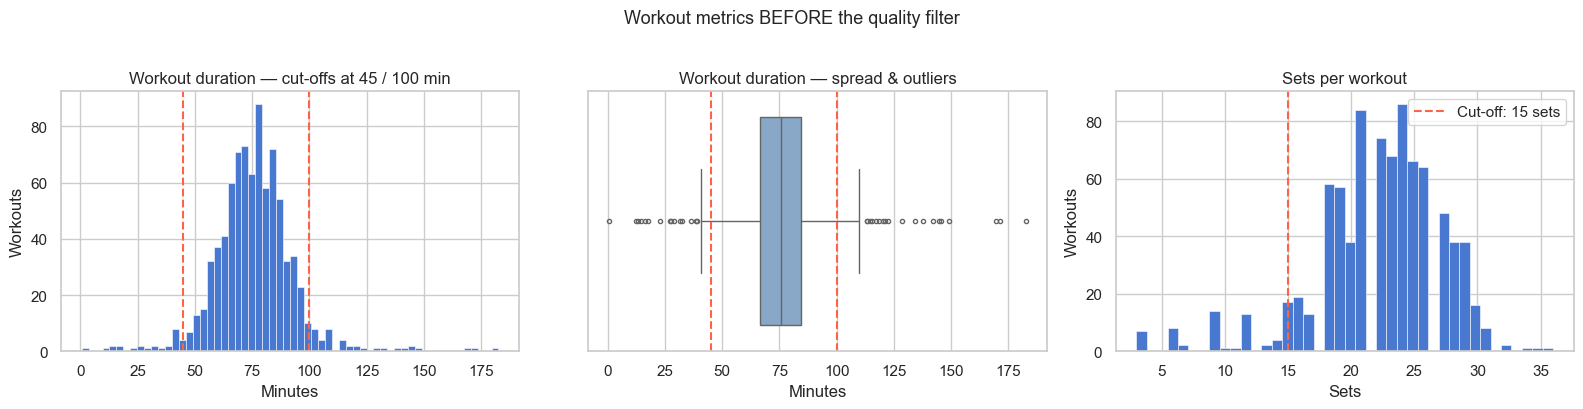

In [23]:
MIN_DURATION, MAX_DURATION, MIN_SETS = 45, 100, 15

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(workout_summary_all["duration_min"], bins=60, edgecolor="white", linewidth=0.4)
for v in (MIN_DURATION, MAX_DURATION):
    axes[0].axvline(v, color="tomato", ls="--", lw=1.5)
axes[0].set(title="Workout duration — cut-offs at 45 / 100 min", xlabel="Minutes", ylabel="Workouts")

sns.boxplot(x=workout_summary_all["duration_min"], ax=axes[1], color="#7fa8d1", fliersize=3)
for v in (MIN_DURATION, MAX_DURATION):
    axes[1].axvline(v, color="tomato", ls="--", lw=1.5)
axes[1].set(title="Workout duration — spread & outliers", xlabel="Minutes")

axes[2].hist(workout_summary_all["total_sets"], bins=40, edgecolor="white", linewidth=0.4)
axes[2].axvline(MIN_SETS, color="tomato", ls="--", lw=1.5, label=f"Cut-off: {MIN_SETS} sets")
axes[2].set(title="Sets per workout", xlabel="Sets", ylabel="Workouts")
axes[2].legend()

plt.suptitle("Workout metrics BEFORE the quality filter", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

In [24]:
reasons = pd.DataFrame({
    "duration < 45 min": workout_summary_all["duration_min"] < MIN_DURATION,
    "duration > 100 min": workout_summary_all["duration_min"] > MAX_DURATION,
    "fewer than 15 sets": workout_summary_all["total_sets"] < MIN_SETS,
})

breakdown = reasons.sum().rename("workouts").to_frame()
breakdown["% of all"] = (breakdown["workouts"] / len(workout_summary_all) * 100).round(1)
print("Exclusions by reason (a workout can trigger more than one):")
print(breakdown.to_string())

excluded = reasons.any(axis=1)
print(f"\nExcluded in total: {excluded.sum()} of {len(workout_summary_all)} "
      f"({excluded.mean() * 100:.1f}%)")

cols = ["date", "workout_name", "duration_min", "total_sets", "total_volume_kg"]
print("\nShortest excluded sessions:")
print(workout_summary_all[excluded].nsmallest(3, "duration_min")[cols].to_string(index=False))
print("\nLongest excluded sessions:")
print(workout_summary_all[excluded].nlargest(3, "duration_min")[cols].to_string(index=False))

Exclusions by reason (a workout can trigger more than one):
                    workouts  % of all
duration < 45 min         26      3.10
duration > 100 min        39      4.60
fewer than 15 sets        52      6.10

Excluded in total: 93 of 849 (11.0%)

Shortest excluded sessions:
               date workout_name  duration_min  total_sets  total_volume_kg
2023-03-16 08:16:21       Legs 1          0.60          26         21780.50
2024-05-28 16:29:09     Mobility         12.40           9             0.00
2024-05-09 14:36:04     Mobility         13.20           9             0.00

Longest excluded sessions:
               date            workout_name  duration_min  total_sets  total_volume_kg
2025-06-29 12:44:13        D2 Beine/Rücken         182.60          20          9723.00
2025-10-22 18:16:43           Abend-Workout        171.40           9          2536.00
2025-07-19 20:32:14 D2 Brust/Schultern/Arme        169.40          20          7862.25


In [25]:
valid_mask = (
    workout_summary_all["duration_min"].between(MIN_DURATION, MAX_DURATION)
    & (workout_summary_all["total_sets"] >= MIN_SETS)
)

workout_summary = workout_summary_all[valid_mask].reset_index(drop=True)

# Propagate the filter to the set level — drop sets of excluded workouts
valid_ids = set(workout_summary["workout_id"])
df_sets = df_sets[df_sets["workout_id"].isin(valid_ids)].copy()

print(f"Workouts excluded : {(~valid_mask).sum()}")
print(f"Workouts remaining: {len(workout_summary):,}")
print(f"Sets remaining    : {len(df_sets):,}")
workout_summary.head(5)

Workouts excluded : 93
Workouts remaining: 756
Sets remaining    : 17,397


,workout_id,date,workout_name,total_sets,total_volume_kg,peak_estimated_1rm,unique_exercises,duration_min
0,1,2020-05-28 12:58:47,Day 3,19,8557.50,260.00,6,69.90
1,4,2020-06-03 16:02:10,Day 1,22,13864.00,273.33,7,79.60
2,5,2020-06-05 17:21:14,Day 2,19,14442.00,316.67,6,81.60
3,6,2020-06-07 15:19:22,Day 3,22,11758.75,273.33,6,68.50
4,7,2020-06-08 16:12:58,Day 4,18,6577.50,77.00,6,72.60


### Sensitivity check — does the filter change the conclusions?

Removing 11% of the sessions is only defensible if the findings survive it. Below, the central
per-workout statistics and the monthly volume trend are computed **both ways**.

Median per workout, with and without the quality filter:
                  unfiltered (n=849)  filtered (n=756)  change %
duration_min                   75.90             75.70     -0.30
total_sets                     23.00             23.00      0.00
total_volume_kg             10039.20          10664.00      6.20
unique_exercises                6.00              6.00      0.00


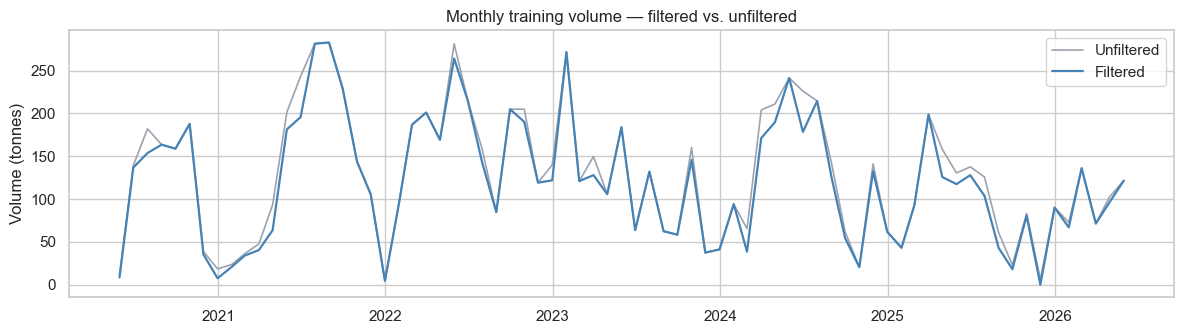


Correlation of the two monthly series: r = 0.988


In [26]:
# Sensitivity check: do the headline numbers depend on the filter?
metrics = ["duration_min", "total_sets", "total_volume_kg", "unique_exercises"]

comparison = pd.DataFrame({
    "unfiltered (n=%d)" % len(workout_summary_all): workout_summary_all[metrics].median(),
    "filtered (n=%d)" % len(workout_summary): workout_summary[metrics].median(),
})
comparison["change %"] = (
    (comparison.iloc[:, 1] - comparison.iloc[:, 0]) / comparison.iloc[:, 0] * 100
).round(1)
print("Median per workout, with and without the quality filter:")
print(comparison.round(1).to_string())

# And does the volume trend over time survive the filter?
monthly_all = (workout_summary_all.set_index("date")
               .resample("ME")["total_volume_kg"].sum().rename("unfiltered"))
monthly_flt = (workout_summary.set_index("date")
               .resample("ME")["total_volume_kg"].sum().rename("filtered"))
monthly = pd.concat([monthly_all, monthly_flt], axis=1).fillna(0)

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(monthly.index, monthly["unfiltered"] / 1000, label="Unfiltered", lw=1.2, color="#9ca3af")
ax.plot(monthly.index, monthly["filtered"] / 1000, label="Filtered", lw=1.6, color="steelblue")
ax.set(title="Monthly training volume — filtered vs. unfiltered",
       xlabel="", ylabel="Volume (tonnes)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nCorrelation of the two monthly series: r = {monthly['unfiltered'].corr(monthly['filtered']):.3f}")

**Result: the filter is safe.** Median duration and set count are essentially unchanged
(−0.3% and 0%), and median volume per session rises by 6.2% — expected, since the excluded sessions
are the fragmentary ones. The monthly volume series correlates at **r = 0.988** between the filtered
and unfiltered data, so the shape of the six-year trend — the basis for RQ1 — does not depend on this
decision. The filter removes noise, not signal.

Excluded sessions are also plausible as errors rather than real training: a 26-set session recorded
as 0.6 minutes (timer never started), mobility sessions of 9 sets and zero load, and 170-minute
"workouts" (timer left running).

In [27]:
# Quick descriptive summary — validates that aggregated numbers are in a plausible range
workout_summary[["duration_min", "total_sets", "total_volume_kg", "unique_exercises"]].describe().round(1)

,duration_min,total_sets,total_volume_kg,unique_exercises
count,756.00,756.00,756.00,756.00
mean,75.10,23.00,11688.60,6.40
std,11.40,3.70,6444.80,0.90
min,47.20,15.00,0.00,4.00
25%,67.10,20.80,6841.10,6.00
50%,75.70,23.00,10664.00,6.00
75%,83.40,26.00,15964.20,7.00
max,99.90,35.00,35145.00,9.00


## 6. Export

Write both datasets to `data/clean/`. These files are the single source of truth for all downstream analysis (SQL, Power BI, statistics notebook).

In [28]:
# Select and order columns for the sets export
SETS_COLUMNS = [
    "workout_id", "date", "workout_name", "year", "month", "week", "day_of_week",
    "exercise_name", "set_order", "weight_kg", "reps", "rpe",
    "volume_kg", "estimated_1rm",
    "notes",
]

clean_sets = df_sets[SETS_COLUMNS].sort_values(["date", "workout_id", "exercise_name", "set_order"])

clean_sets_path = CLEAN_DIR / "clean_sets.csv"
clean_sets.to_csv(clean_sets_path, index=False)
print(f"Exported {len(clean_sets):,} rows → {clean_sets_path}")

Exported 17,397 rows → ..\data\clean\clean_sets.csv


In [29]:
workout_summary_path = CLEAN_DIR / "workout_summary.csv"
workout_summary.to_csv(workout_summary_path, index=False)
print(f"Exported {len(workout_summary):,} rows → {workout_summary_path}")

Exported 756 rows → ..\data\clean\workout_summary.csv


In [30]:
# Final summary — confirm output looks correct before handing off to Phase 2
print("=== clean_sets.csv ===")
print(f"  Rows         : {len(clean_sets):,}")
print(f"  Date range   : {clean_sets['date'].min().date()} → {clean_sets['date'].max().date()}")
print(f"  Exercises    : {clean_sets['exercise_name'].nunique()}")
print()
print("=== workout_summary.csv ===")
print(f"  Rows         : {len(workout_summary):,}")
print(f"  Avg duration : {workout_summary['duration_min'].mean():.1f} min")
print(f"  Avg volume   : {workout_summary['total_volume_kg'].mean():,.0f} kg")
print(f"  Avg sets     : {workout_summary['total_sets'].mean():.1f}")

=== clean_sets.csv ===
  Rows         : 17,397
  Date range   : 2020-05-28 → 2026-05-27
  Exercises    : 107

=== workout_summary.csv ===
  Rows         : 756
  Avg duration : 75.1 min
  Avg volume   : 11,689 kg
  Avg sets     : 23.0
